In [1]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append(".")
import os
os.chdir('/content/drive/MyDrive/olist-customer-intelligence')

import sys
sys.path.append(".")
from src.data_loader import run_query
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)

segments = pd.read_csv("data/processed/customer_segments.csv")
print(segments.shape)
segments["segment"].value_counts()

Mounted at /content/drive
(93358, 9)


,count
segment,
Low-Value Recent,35248
High-Value One-Timers,31024
Dormant Low-Value,24285
Repeat Buyers,2801


In [ ]:
first_order_sql = """
    WITH first_order AS (
        SELECT
            c.customer_unique_id,
            o.order_id,
            o.order_purchase_timestamp,
            ROW_NUMBER() OVER (
                PARTITION BY c.customer_unique_id
                ORDER BY o.order_purchase_timestamp
            ) AS order_rank
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
    ),
    fo AS (SELECT * FROM first_order WHERE order_rank = 1),
    order_value AS (
        SELECT oi.order_id,
               COUNT(*)               AS first_n_items,
               SUM(oi.price)          AS first_items_value,
               SUM(oi.freight_value)  AS first_freight,
               AVG(oi.price)          AS first_avg_item_price
        FROM order_items oi GROUP BY 1
    ),
    pay AS (
        SELECT order_id,
               MAX(payment_installments) AS first_installments,
               COUNT(DISTINCT payment_type) AS first_n_payment_types,
               SUM(payment_value)           AS first_payment_value
        FROM order_payments GROUP BY 1
    ),
    cat AS (
        SELECT order_id, category_en FROM (
            SELECT oi.order_id,
                   COALESCE(t.product_category_name_english,
                            p.product_category_name, 'unknown') AS category_en,
                   ROW_NUMBER() OVER (PARTITION BY oi.order_id
                                      ORDER BY COUNT(*) DESC) AS rn
            FROM order_items oi
            JOIN products p ON oi.product_id = p.product_id
            LEFT JOIN category_translation t
                   ON p.product_category_name = t.product_category_name
            GROUP BY oi.order_id, 2
        ) WHERE rn = 1
    )
    SELECT
        fo.customer_unique_id,
        fo.order_id,
        ov.first_n_items,
        ov.first_items_value,
        ov.first_freight,
        ov.first_avg_item_price,
        pay.first_installments,
        pay.first_n_payment_types,
        pay.first_payment_value,
        cat.category_en                              AS first_category,
        cust.customer_state,
        EXTRACT('dow'   FROM fo.order_purchase_timestamp) AS first_order_dow,
        EXTRACT('month' FROM fo.order_purchase_timestamp) AS first_order_month
    FROM fo
    JOIN order_value ov ON fo.order_id = ov.order_id
    LEFT JOIN pay       ON fo.order_id = pay.order_id
    LEFT JOIN cat       ON fo.order_id = cat.order_id
    JOIN customers cust ON fo.customer_unique_id = cust.customer_unique_id
"""
first_feats = run_query(first_order_sql)
print(first_feats.shape)
first_feats.head()

(96683, 13)


,customer_unique_id,order_id,first_n_items,first_items_value,first_freight,first_avg_item_price,first_installments,first_n_payment_types,first_payment_value,first_category,customer_state,first_order_dow,first_order_month
0,708ab75d2a007f0564aedd11139c7708,b81ef226f3fe1789b1e8b2acac839d17,1,79.80,19.53,79.80,8,1,99.33,home_construction,MG,3,4
1,a8b9d3a27068454b1c98cc67d4e31e6f,a9810da82917af2d9aefd1278f1dcfa0,1,17.00,7.39,17.00,1,1,24.39,auto,SP,2,6
2,6f70c0b2f7552832ba46eb57b1c5651e,25e8ea4e93396b6fa0d3dd708e76c1bd,1,56.99,8.72,56.99,1,1,65.71,perfumery,SP,2,12
3,87695ed086ebd36f20404c82d20fca87,ba78997921bbcdc1373bb41e913ab953,1,89.90,17.88,89.90,8,1,107.78,bed_bath_table,MG,3,12
4,2ecddf370925aff428e58b4f6021fe38,1f78449c87a54faf9e96e88ba1491fa9,1,269.00,72.09,269.00,6,1,341.09,auto,PB,0,7


In [ ]:
from src.segmentation import REGION_MAP

df = first_feats.merge(
    segments[["customer_unique_id", "segment", "cluster"]],
    on="customer_unique_id", how="inner"
)
df = df.drop_duplicates("customer_unique_id")  # one row per customer

df["region"] = df["customer_state"].map(REGION_MAP).fillna("unknown")

# Group rare categories
top_cats = df["first_category"].value_counts().head(12).index
df["first_category_grouped"] = np.where(
    df["first_category"].isin(top_cats), df["first_category"], "other")

print(df.shape)
print(df.head())
df["segment"].value_counts()

(93358, 17)
                 customer_unique_id                          order_id  \
0  708ab75d2a007f0564aedd11139c7708  b81ef226f3fe1789b1e8b2acac839d17   
1  a8b9d3a27068454b1c98cc67d4e31e6f  a9810da82917af2d9aefd1278f1dcfa0   
2  6f70c0b2f7552832ba46eb57b1c5651e  25e8ea4e93396b6fa0d3dd708e76c1bd   
3  87695ed086ebd36f20404c82d20fca87  ba78997921bbcdc1373bb41e913ab953   
4  2ecddf370925aff428e58b4f6021fe38  1f78449c87a54faf9e96e88ba1491fa9   

   first_n_items  first_items_value  first_freight  first_avg_item_price  \
0              1              79.80          19.53                 79.80   
1              1              17.00           7.39                 17.00   
2              1              56.99           8.72                 56.99   
3              1              89.90          17.88                 89.90   
4              1             269.00          72.09                269.00   

   first_installments  first_n_payment_types  first_payment_value  \
0                   8  

,count
segment,
Low-Value Recent,35248
High-Value One-Timers,31024
Dormant Low-Value,24285
Repeat Buyers,2801


In [ ]:
feature_cols_num = ["first_n_items", "first_items_value", "first_freight",
                    "first_avg_item_price", "first_installments",
                    "first_n_payment_types", "first_payment_value",
                    "first_order_dow", "first_order_month"]
feature_cols_cat = ["region", "first_category_grouped"]

# Target A: full 4-class segment
y_multi = df["segment"]

# Target B: binary "high-value" = High-Value One-Timers OR Repeat Buyers
high_value_segments = ["High-Value One-Timers", "Repeat Buyers"]
y_binary = df["segment"].isin(high_value_segments).astype(int)

print("Binary positive rate:", y_binary.mean().round(3))
X = df[feature_cols_num + feature_cols_cat]

Binary positive rate: 0.362


In [ ]:
from sklearn.impute import SimpleImputer

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), feature_cols_num),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="unknown")),
        ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), feature_cols_cat),
])

X_train, X_test, ym_train, ym_test, yb_train, yb_test = train_test_split(
    X, y_multi, y_binary, test_size=0.25, random_state=42, stratify=y_multi)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (70018, 11) Test: (23340, 11)


In [ ]:
binary_clf = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=12,
                                   class_weight="balanced",
                                   random_state=42, n_jobs=-1)),
])
binary_clf.fit(X_train, yb_train)

yb_proba = binary_clf.predict_proba(X_test)[:, 1]
yb_pred = binary_clf.predict(X_test)

print("Binary ROC-AUC:", round(roc_auc_score(yb_test, yb_proba), 4))
print(classification_report(yb_test, yb_pred,
                            target_names=["not high-value", "high-value"]))

Binary ROC-AUC: 0.9688
                precision    recall  f1-score   support

not high-value       0.96      0.93      0.95     14884
    high-value       0.89      0.94      0.91      8456

      accuracy                           0.93     23340
     macro avg       0.93      0.94      0.93     23340
  weighted avg       0.94      0.93      0.94     23340



In [ ]:
multi_clf = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=12,
                                   class_weight="balanced",
                                   random_state=42, n_jobs=-1)),
])
multi_clf.fit(X_train, ym_train)

ym_proba = multi_clf.predict_proba(X_test)
ym_pred = multi_clf.predict(X_test)

# Macro one-vs-rest AUC for multi-class
auc_multi = roc_auc_score(ym_test, ym_proba, multi_class="ovr",
                          average="macro", labels=multi_clf.classes_)
print("Multi-class macro OVR AUC:", round(auc_multi, 4))
print(classification_report(ym_test, ym_pred))

Multi-class macro OVR AUC: 0.8526
                       precision    recall  f1-score   support

    Dormant Low-Value       0.76      0.56      0.64      6072
High-Value One-Timers       0.87      0.99      0.93      7756
     Low-Value Recent       0.79      0.90      0.84      8812
        Repeat Buyers       0.20      0.01      0.02       700

             accuracy                           0.81     23340
            macro avg       0.65      0.62      0.61     23340
         weighted avg       0.79      0.81      0.79     23340



In [ ]:
lr_binary = Pipeline([("prep", preprocess),
                      ("clf", LogisticRegression(max_iter=1000,
                                                 class_weight="balanced"))])
lr_binary.fit(X_train, yb_train)
lr_auc = roc_auc_score(yb_test, lr_binary.predict_proba(X_test)[:, 1])
print(f"Binary AUC — LogReg: {lr_auc:.4f} | RandomForest: "
      f"{roc_auc_score(yb_test, yb_proba):.4f}")

Binary AUC — LogReg: 0.9545 | RandomForest: 0.9688


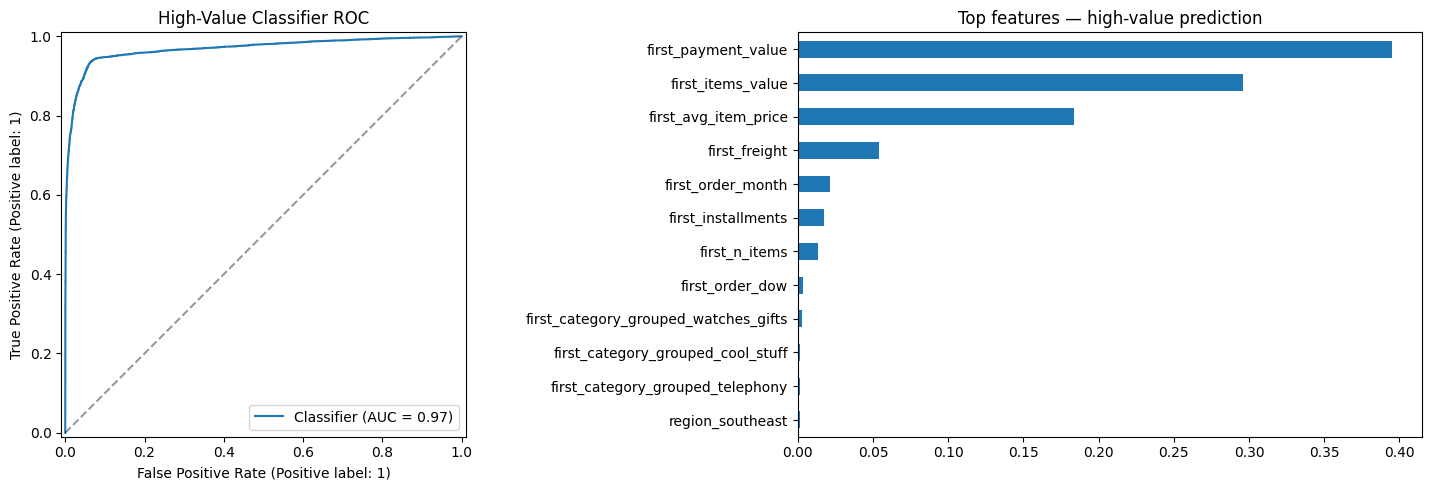

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

RocCurveDisplay.from_predictions(yb_test, yb_proba, ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_title("High-Value Classifier ROC")

# RF feature importances mapped back to names
feat_names = (feature_cols_num +
              list(binary_clf.named_steps["prep"]
                   .named_transformers_["cat"]
                   .get_feature_names_out(feature_cols_cat)))
importances = binary_clf.named_steps["clf"].feature_importances_
imp = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(12)
imp.iloc[::-1].plot(kind="barh", ax=axes[1])
axes[1].set_title("Top features — high-value prediction")
plt.tight_layout()

In [ ]:
joblib.dump(binary_clf, "models/segment_classifier.pkl")
joblib.dump(multi_clf, "models/segment_classifier_multiclass.pkl")
print("Saved both classifiers.")

Saved both classifiers.


In [ ]:
%%writefile src/predictor.py
"""Early-lifecycle segment / high-value prediction.

LEAKAGE FIREWALL: features use FIRST-ORDER quantities only. We deliberately
exclude lifetime recency/frequency/monetary/aov — the aggregates that DEFINED
the segments — so the model answers a genuine predictive question rather than
reverse-engineering the clustering boundaries.
"""
import joblib
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

FEATURE_COLS_NUM = ["first_n_items", "first_items_value", "first_freight",
                    "first_avg_item_price", "first_installments",
                    "first_n_payment_types", "first_payment_value",
                    "first_order_dow", "first_order_month"]
FEATURE_COLS_CAT = ["region", "first_category_grouped"]
HIGH_VALUE_SEGMENTS = ["High-Value One-Timers", "Repeat Buyers"]


def build_pipeline() -> Pipeline:
    prep = ColumnTransformer([
        ("num", StandardScaler(), FEATURE_COLS_NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         FEATURE_COLS_CAT),
    ])
    return Pipeline([
        ("prep", prep),
        ("clf", RandomForestClassifier(n_estimators=300, max_depth=12,
                                       class_weight="balanced",
                                       random_state=42, n_jobs=-1)),
    ])


def predict_high_value(model, first_order_features: pd.DataFrame) -> np.ndarray:
    """Return P(high-value) for new customers given first-order features."""
    return model.predict_proba(first_order_features)[:, 1]


def load_classifier(path="models/segment_classifier.pkl"):
    return joblib.load(path)

Writing src/predictor.py


## Summary — Predictive Segments

**Goal:** Predict a customer's value segment from EARLY-LIFECYCLE (first-order)
features only — no leakage from the lifetime aggregates that defined segments.

**Leakage firewall**
- Features restricted to first-order quantities: first_items_value, first_freight,
  first_payment_value, first_avg_item_price, installments, n_items, category,
  region, order day/month.
- Deliberately EXCLUDED lifetime recency/frequency/monetary/aov (the segment-
  defining aggregates). Documented as the anti-circularity measure.
- Data-quality note: some delivered orders lacked payment records → median/
  constant imputation added to the pipeline (also makes deployment robust).

**Two models built**
- Binary "high-value" (High-Value One-Timers + Repeat Buyers): ROC-AUC 0.97
  (RF) vs LogReg baseline. Strong — BUT driven almost entirely by first-order
  spend (first_payment_value/items_value/avg_item_price). Honest read: for the
  ~96% who order once, first-order value ≈ their monetary, so this is close to
  a definitional relationship, not a sophisticated lifecycle model.
- Multi-class 4-segment: macro OVR AUC 0.85, accuracy 0.81.

**The real finding (a documented negative result)**
- Repeat Buyers class: precision 0.20, recall 0.01, f1 0.02. The model
  essentially CANNOT identify future repeat buyers from first-order data.
- Insight: spend level is predictable early; LOYALTY is not. Olist cannot
  flag future-loyal customers at acquisition — loyalty must be created
  post-purchase, not predicted. This motivates the Day 18 causal question.

**Deliverables created**
- models/segment_classifier.pkl (binary, deployable)
- models/segment_classifier_multiclass.pkl
- src/predictor.py